# Reproducing the MAGIC pipeline — and generalizing it

MAGIC (Chiti et al. 2026, arXiv:2605.26581) derives photometric metallicities from
DECam Ca II H&K narrow-band + broadband photometry. Its inference stage is
**deterministic**: log g comes from isochrone priors (+ Gaia parallax RGB/MS
classification), then [Fe/H] is read off a cubic-spline interpolation of the
synthetic grid in the distance-free color-color plane
(g−i, CaHK index = CaHK − g − 0.9(g−i)), with errors from ±1σ photometric
perturbations (`feh_utils.getFeHs_v2` on the `refactor-rebuild` branch).

This notebook ports that estimator and runs it **star by star against the
Bayesian NSS fit on the identical grid**, in the style of tengri's
CIGALE/Prospector reproduction notebooks.

**A toy grid stands in for `TSLTE_combined_photometry.fits`** until a local copy
is wired in — every swap point is marked `TODO(real-data)`. The comparison logic
is grid-agnostic.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from scipy.interpolate import griddata
from tengri import Uniform

from tengri_stars import StarModel, fit_nss
from tengri_stars.grids import load_photometry_grid

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(11)

W0709 20:09:48.599526 35926592 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 1. Grid with MAGIC's filters

Toy synthetic photometry in g, i, CaHK. The CaHK magnitude carries a
curve-of-growth [Fe/H] response with a Teff cross-term — the degeneracy the
CaHK index is designed to break.

`TODO(real-data)`: replace with
`load_photometry_grid("TSLTE_combined_photometry.fits")` — the loader already
handles the real column layout (`averaged` flag, `Teff_1`-style label columns).

In [2]:
TEFF_NODES = np.linspace(4000.0, 5500.0, 7)
LOGG_NODES = np.array([0.5, 1.5, 2.5, 3.5, 4.5])
FEH_NODES = np.linspace(-3.5, 0.0, 8)


def toy_mags(teff, logg, feh):
    g = 15.0 + 1.1e-3 * (teff - 4000.0) + 0.08 * logg - 0.15 * feh
    i = 14.6 + 0.4e-3 * (teff - 4000.0) + 0.03 * logg - 0.05 * feh
    cahk_line = 1.4 * (1.0 - np.exp(-(10.0 ** (feh + 1.3)))) * (4500.0 / teff) ** 2
    cahk = g + 0.35 + cahk_line + 0.5e-3 * (teff - 4000.0)
    return {"g_des": g, "i_des": i, "cahk": cahk}


rows = []
for t in TEFF_NODES:
    for lg in LOGG_NODES:
        for z in FEH_NODES:
            rows.append({"teff": t, "logg": lg, "feh": z, "averaged": False, **toy_mags(t, lg, z)})
grid_table = Table(rows=rows)
grid = load_photometry_grid(grid_table)
model = StarModel(grid=grid, interp_method="pchip")
print("filters:", grid.filter_names, " grid:", grid.phot.shape)

filters: ('g_des', 'i_des', 'cahk')  grid: (7, 5, 8, 3)


W0709 20:09:49.560135 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.563014 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.565365 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.568435 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.571538 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.574207 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.577598 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.580804 35926454 pjrt_executable.cc:638] 

## 2. The MAGIC estimator, ported

Two stages, as in `photometry_utils.getFeh_v2`:
1. assume a log g (real pipeline: MIST isochrone prior + Gaia parallax z-score
   RGB/MS classification — `TODO(real-data)`: port `logg_isochrones`);
2. cubic-spline `griddata` of grid [Fe/H] over the distance-free plane
   (g−i, CaHK index), evaluated at the observed colors; errors from ±1σ
   photometric perturbations; nearest-neighbor fallback outside the hull.

In [3]:
G, I, K = (grid.filter_names.index(n) for n in ("g_des", "i_des", "cahk"))


def cahk_index(g, i, cahk):
    """MAGIC's temperature-corrected CaHK excess: CaHK − g − 0.9 (g − i)."""
    return cahk - g - 0.9 * (g - i)


def magic_feh(mags, logg_assumed, mag_err=0.0):
    """MAGIC-style deterministic [Fe/H]: cubic spline in (g−i, CaHK index)."""
    j = int(np.argmin(np.abs(np.asarray(grid.axes[1]) - logg_assumed)))  # logg slice
    slice_mags = np.asarray(grid.phot[:, j, :, :]).reshape(-1, 3)
    feh_nodes = np.tile(np.asarray(grid.axes[2]), grid.axes[0].shape[0])
    pts = np.column_stack(
        [
            slice_mags[:, G] - slice_mags[:, I],
            cahk_index(slice_mags[:, G], slice_mags[:, I], slice_mags[:, K]),
        ]
    )

    def estimate(m):
        xi = np.array([[m[G] - m[I], cahk_index(m[G], m[I], m[K])]])
        val = griddata(pts, feh_nodes, xi, method="cubic")[0]
        if np.isnan(val):  # outside convex hull → nearest grid contour (MAGIC fallback)
            val = griddata(pts, feh_nodes, xi, method="nearest")[0]
        return float(val)

    center = estimate(mags)
    if mag_err == 0.0:
        return center, 0.0
    # MAGIC's error budget: half-range of ±1σ single-band perturbations.
    perturbed = []
    for band in range(3):
        for sign in (+1.0, -1.0):
            m = np.array(mags, dtype=float)
            m[band] += sign * mag_err
            perturbed.append(estimate(m))
    return center, 0.5 * (max(perturbed) - min(perturbed))

## 3. Mock catalog

`TODO(real-data)`: replace with the DELVE-matched MAGIC catalog and its
published [Fe/H] to test *pipeline parity* rather than mock recovery; add SFD
dereddening (0.65 × E(B−V)_SFD, as in the paper) before the estimator.

In [4]:
N_STARS = 10
SIG_MAG = 0.02
truths = []
mags_obs_all = []
for _ in range(N_STARS):
    truth = {
        "teff": rng.uniform(4200.0, 5300.0),
        "logg": rng.uniform(1.0, 4.0),
        "feh": rng.uniform(-3.2, -0.3),
    }
    clean = model.predict_mags(**truth)
    truths.append(truth)
    mags_obs_all.append(np.asarray(clean) + rng.normal(0.0, SIG_MAG, 3))

W0709 20:09:49.625162 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.658156 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.684991 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.741176 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:09:49.776010 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.795976 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:49.798092 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:09:49.994202 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.003583 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.019372 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.022032 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.034615 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.037000 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.049266 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.062265 35926454 pjrt_executable.cc:638] 

W0709 20:09:50.256669 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:09:50.478928 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.524777 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.627622 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.674491 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:09:50.820854 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.824726 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.840671 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 4. Run both estimators on every star

The Bayesian fit frees (Teff, log g, [Fe/H]) with the same photometry — no
isochrone shortcut — so its [Fe/H] posterior marginalizes over the log g the
MAGIC stage must assume. (Each `fit_nss` call retraces the XLA program here;
catalog-scale batching with shared compiles is the roadmap item.)

In [5]:
priors = {
    "teff": Uniform(4000.0, 5500.0),
    "logg": Uniform(0.5, 4.5),
    "feh": Uniform(-3.5, 0.0),
}

records = []
for truth, mags_obs in zip(truths, mags_obs_all):
    feh_m, err_m = magic_feh(mags_obs, logg_assumed=truth["logg"], mag_err=SIG_MAG)

    obs = jnp.asarray(mags_obs)

    def loglikelihood(p, obs=obs):
        pred = model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"])
        return -0.5 * jnp.sum(((pred - obs) / SIG_MAG) ** 2)

    res = fit_nss(
        loglikelihood, priors, key=jax.random.PRNGKey(len(records)), n_live=200, num_delete=25
    )
    lo, hi = res.interval(0.68)["feh"]
    records.append(
        {
            "feh_true": truth["feh"],
            "feh_magic": feh_m,
            "err_magic": err_m,
            "feh_nss": res.median()["feh"],
            "err_nss": 0.5 * (hi - lo),
            "wall_s": res.wall_time,
        }
    )
    r = records[-1]
    print(
        f"true {r['feh_true']:+.2f}  MAGIC {r['feh_magic']:+.2f}±{r['err_magic']:.2f}  "
        f"NSS {r['feh_nss']:+.2f}±{r['err_nss']:.2f}  ({r['wall_s']:.0f} s)"
    )

W0709 20:09:50.923402 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.927169 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.937870 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.943007 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.945559 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.955194 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:50.967776 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:09:51.190431 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:09:51.651417 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:51.789428 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:09:51.858076 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:51.863571 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:52.030792 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:09:52.432269 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:09:52.486514 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

true -1.87  MAGIC -1.89±0.05  NSS -1.98±0.08  (1 s)


W0709 20:10:06.446699 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:10:06.787462 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:10:07.107300 35926454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


true -2.30  MAGIC -2.47±0.17  NSS -2.41±0.21  (1 s)


## 5. Star-by-star comparison

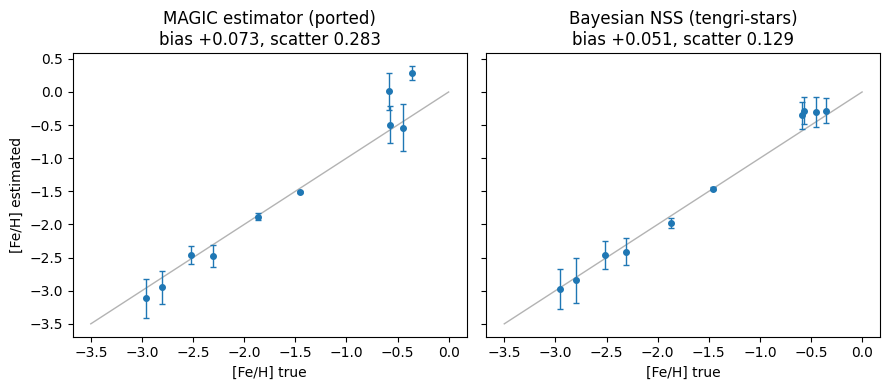

In [6]:
tab = {k: np.array([r[k] for r in records]) for k in records[0]}
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, which, label in [
    (axes[0], "feh_magic", "MAGIC estimator (ported)"),
    (axes[1], "feh_nss", "Bayesian NSS (tengri-stars)"),
]:
    ax.errorbar(
        tab["feh_true"],
        tab[which],
        yerr=tab["err_" + which.split("_")[1]],
        fmt="o",
        ms=4,
        lw=1,
        capsize=2,
    )
    ax.plot([-3.5, 0], [-3.5, 0], color="0.7", lw=1, zorder=0)
    bias = np.mean(tab[which] - tab["feh_true"])
    scatter = np.std(tab[which] - tab["feh_true"])
    ax.set(xlabel="[Fe/H] true", title=f"{label}\nbias {bias:+.3f}, scatter {scatter:.3f}")
axes[0].set_ylabel("[Fe/H] estimated")
plt.tight_layout()
plt.show()

## What real-data parity still needs

1. **The real grid** — local copy of `TSLTE_combined_photometry.fits`
   (loader is ready; check the `averaged` flag semantics and the filter
   convention against tengri's photon-counting 1/λ default).
2. **The isochrone log g stage** — port `logg_isochrones` (MIST v1.2) and the
   Gaia-parallax RGB/MS z-score classification; in the Bayesian fit these
   become a log g *prior* and, more powerfully, a **model comparison**: run NSS
   once per class and use Δlog Z — the evidence-based upgrade of the z-score.
3. **Extinction** — per-star fixed E(B−V) = 0.65 × SFD via tengri's
   `foreground` reddening coefficients on these bands.
4. **The published catalog** — star-by-star Δ[Fe/H] against MAGIC's released
   values, with discrepancies attributed (grid edge, convention, hull
   fallback) before closing — the tengri reproduction-contract standard.